In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
#data_loading_splitting_normlize
(X_train,y_train) , (X_test,y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [12]:
#simple_Dense_NN
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(units=128 , activation='relu'),
    tf.keras.layers.Dense(units=32 , activation='relu'),
    tf.keras.layers.Dense(units=10 , activation='softmax')
    ]) 
#early stop to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3)
model.compile(optimizer='adam',
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

c:\Users\hamom\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
#train
history = model.fit(X_train,y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=1,
                    callbacks =[early_stop]
                    )

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8885 - loss: 0.4057 - val_accuracy: 0.9428 - val_loss: 0.1974
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9522 - loss: 0.1651 - val_accuracy: 0.9592 - val_loss: 0.1401
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9668 - loss: 0.1136 - val_accuracy: 0.9686 - val_loss: 0.1109
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 0.0878 - val_accuracy: 0.9696 - val_loss: 0.1040
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9796 - loss: 0.0678 - val_accuracy: 0.9705 - val_loss: 0.0984
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0566 - val_accuracy: 0.9730 - val_loss: 0.0919
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9868 - loss: 0.0454 - val_accuracy: 0.9722 - val_loss: 0.0918
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9893 - loss: 0.0375 - val_accuracy: 0.

In [14]:
#evaluate
results = model.evaluate(X_test,y_test)
print(f"Test loss {results[0]} , Accuracy {results[1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9747 - loss: 0.0873
Test loss 0.08730456233024597 , Accuracy 0.9746999740600586


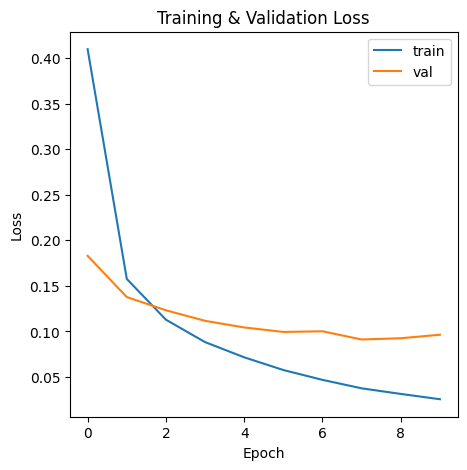

In [6]:
#plotting_the_loss
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'] , label='train')
plt.plot(history.history['val_loss'],label='val')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted digit: 1


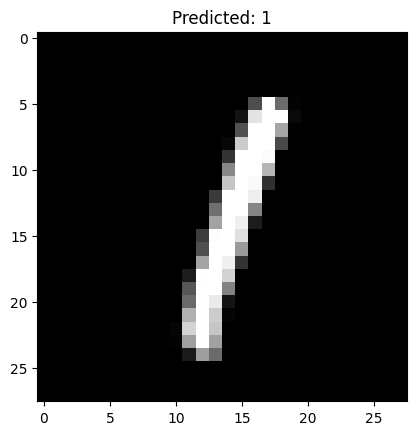

In [11]:
#predict on a sample image
sample = X_test[5]
prediction = model.predict(sample.reshape(1, 28, 28))
predicted_digit = prediction.argmax()
print(f"Predicted digit: {predicted_digit}")

# Plot the predicted number
plt.imshow(sample, cmap='gray')
plt.title(f'Predicted: {predicted_digit}')
plt.show()

In [8]:
#save the model
model.save('mnist_model.keras')
print("Model saved successfully!")

Model saved successfully!
